
Running Q3: Loss vs Number of Hidden Layers...


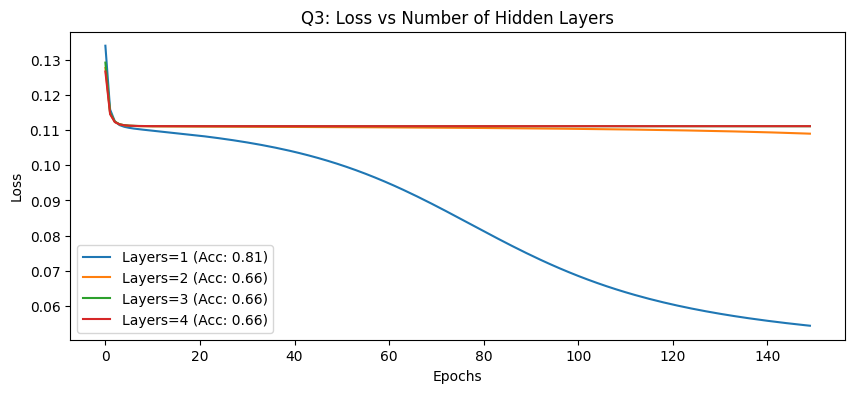

Optimal Layers: 1

Running Q4: Loss vs Number of Hidden Nodes...


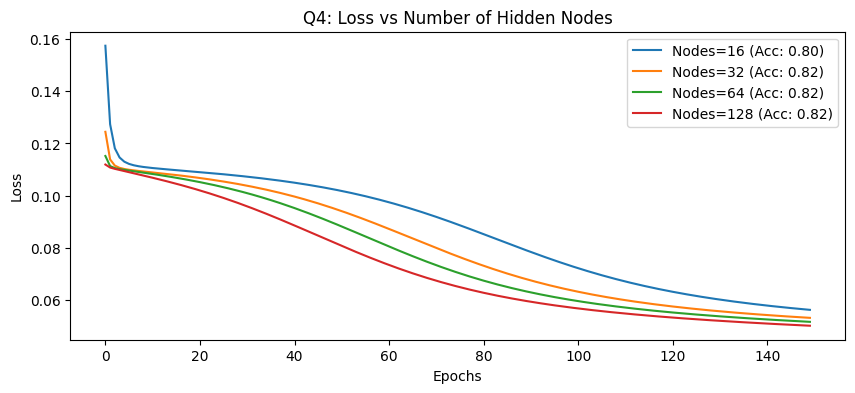

Optimal Nodes: 64

Running Q5: Activation Comparison...


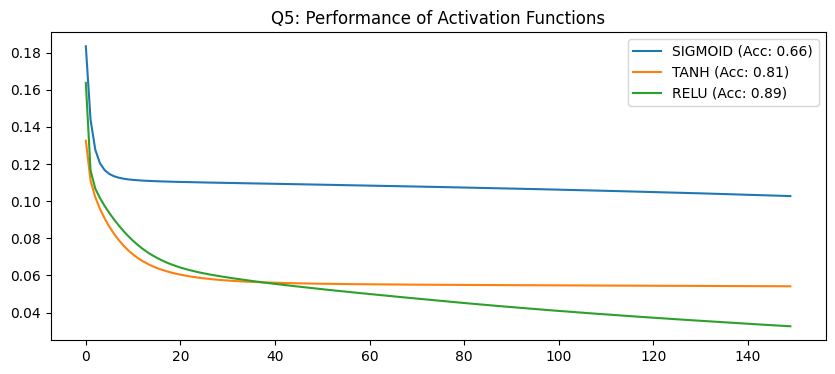


Running Q6: Minibatch Size Comparison...


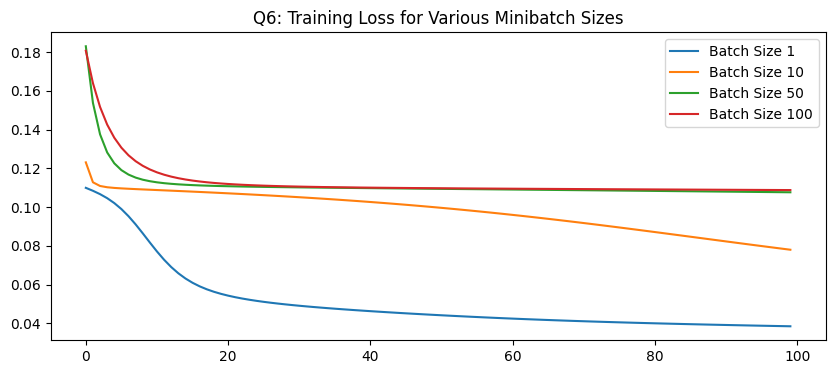

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# 1. LOAD & PREPROCESS (Assumes 'car.data' exists) [cite: 4, 5]
def load_car_data():
    columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'target']
    df = pd.read_csv('car.data', names=columns)

    # One-hot encode features and target [cite: 6]
    X = pd.get_dummies(df.drop('target', axis=1)).values.astype(float)
    y = pd.get_dummies(df['target']).values.astype(float)

    # Manual Split (80% Train, 20% Test)
    indices = np.random.permutation(len(X))
    train_size = int(0.8 * len(X))
    train_idx, test_idx = indices[:train_size], indices[train_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# 2. MULTI-LAYER PERCEPTRON FROM SCRATCH [cite: 6, 7, 8, 9]
class MLP:
    def __init__(self, layers, lr=0.01, act='sigmoid'):
        self.lr = lr
        self.act_type = act
        # Weight initialization [cite: 8]
        self.weights = [np.random.randn(layers[i], layers[i+1]) * 0.1 for i in range(len(layers)-1)]
        self.biases = [np.zeros((1, layers[i+1])) for i in range(len(layers)-1)]

    def _activate(self, x, deriv=False):
        if self.act_type == 'sigmoid':
            s = 1 / (1 + np.exp(-np.clip(x, -500, 500)))
            return s * (1 - s) if deriv else s
        elif self.act_type == 'tanh':
            t = np.tanh(x)
            return (1 - t**2) if deriv else t
        elif self.act_type == 'relu':
            return (x > 0).astype(float) if deriv else np.maximum(0, x)

    def forward(self, X):
        self.activations = [X]
        for w, b in zip(self.weights, self.biases):
            z = self.activations[-1] @ w + b
            self.activations.append(self._activate(z))
        return self.activations[-1]

    def backward(self, y, output):
        # Backpropagation Phase [cite: 8]
        error = output - y
        for i in reversed(range(len(self.weights))):
            delta = error * self._activate(self.activations[i+1], deriv=True)
            grad_w = self.activations[i].T @ delta / y.shape[0]
            grad_b = np.mean(delta, axis=0)

            if i > 0:
                error = delta @ self.weights[i].T

            # Update weights and biases [cite: 9]
            self.weights[i] -= self.lr * grad_w
            self.biases[i] -= self.lr * grad_b

    def fit(self, X, y, epochs=200, batch_size=32):
        losses = []
        for _ in range(epochs):
            for i in range(0, len(X), batch_size):
                xb, yb = X[i:i+batch_size], y[i:i+batch_size]
                self.backward(yb, self.forward(xb))
            losses.append(np.mean(np.square(y - self.forward(X))))
        return losses

# 3. EXPERIMENTATION WRAPPER
X_train, X_test, y_train, y_test = load_car_data()

def run_test(title, param_name, values, fixed_arch_base, is_layers=True):
    print(f"\nRunning {title}...")
    accuracies = []
    plt.figure(figsize=(10, 4))

    for val in values:
        # Construct architecture based on experiment type [cite: 7, 11, 13]
        if is_layers:
            arch = [X_train.shape[1]] + ([32] * val) + [y_train.shape[1]]
        else:
            arch = [X_train.shape[1]] + ([val] * fixed_arch_base) + [y_train.shape[1]]

        nn = MLP(arch, lr=0.05, act='sigmoid')
        losses = nn.fit(X_train, y_train, epochs=150)

        # Performance metric [cite: 10, 12, 14]
        pred = np.argmax(nn.forward(X_test), axis=1)
        acc = np.mean(pred == np.argmax(y_test, axis=1))
        accuracies.append(acc)

        plt.plot(losses, label=f"{param_name}={val} (Acc: {acc:.2f})")

    plt.title(title); plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.show()
    return values[np.argmax(accuracies)]

# --- EXECUTION ---

# Q3: Optimal Layers [cite: 11, 12]
opt_layers = run_test("Q3: Loss vs Number of Hidden Layers", "Layers", [1, 2, 3, 4], None, True)
print(f"Optimal Layers: {opt_layers}")

# Q4: Optimal Nodes [cite: 13, 14]
opt_nodes = run_test("Q4: Loss vs Number of Hidden Nodes", "Nodes", [16, 32, 64, 128], opt_layers, False)
print(f"Optimal Nodes: {opt_nodes}")

# Q5: Compare Activations
print("\nRunning Q5: Activation Comparison...")
arch = [X_train.shape[1]] + ([opt_nodes] * opt_layers) + [y_train.shape[1]]
plt.figure(figsize=(10, 4))
for act in ['sigmoid', 'tanh', 'relu']:
    nn = MLP(arch, lr=0.01, act=act)
    l = nn.fit(X_train, y_train, epochs=150)
    acc = np.mean(np.argmax(nn.forward(X_test), axis=1) == np.argmax(y_test, axis=1))
    plt.plot(l, label=f"{act.upper()} (Acc: {acc:.2f})")
plt.title("Q5: Performance of Activation Functions"); plt.legend(); plt.show()

# Q6: Minibatch Sizes
print("\nRunning Q6: Minibatch Size Comparison...")
plt.figure(figsize=(10, 4))
for bs in [1, 10, 50, 100]:
    nn = MLP(arch, lr=0.01, act='sigmoid')
    l = nn.fit(X_train, y_train, epochs=100, batch_size=bs)
    plt.plot(l, label=f"Batch Size {bs}")
plt.title("Q6: Training Loss for Various Minibatch Sizes"); plt.legend(); plt.show()